# 🏦 Bank Loan Risk Analysis

## Objective
Analyze customer loan data to identify factors influencing loan default risk using Exploratory Data Analysis and machine learning-based feature importance analysis.

In [68]:
## 📚 Import Required Libraries

In [1]:
import pandas as pd
import os

# Show current folder
print("Current folder:")
print(os.getcwd())

# Show files
print("\nFiles:")
print(os.listdir("../Data/raw"))

Current folder:
C:\Users\Administrator\Desktop\Bank-Loan-Risk-Analysis\python

Files:
['Loan_default.csv']


In [2]:
import pandas as pd
import os

# Show current folder
print("Current folder:")
print(os.getcwd())

# Show files
print("\nFiles:")
print(os.listdir("../Data/raw"))

Current folder:
C:\Users\Administrator\Desktop\Bank-Loan-Risk-Analysis\python

Files:
['Loan_default.csv']


In [73]:
## 📂 Data Loading

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("../Data/raw/Loan_default.csv")

# Show first 5 rows
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [74]:
## 🔍 Data Exploration

In [4]:
df.shape

(255347, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [75]:
## 🧹 Data Cleaning & Preprocessing

In [7]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [9]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [10]:
df.sample(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
166661,7168U8Y8AO,48,135861,128128,484,85,3,3.78,12,0.50,High School,Part-time,Single,No,Yes,Business,Yes,0
93075,CGIUKS7J67,38,122965,129520,712,71,2,2.47,60,0.60,High School,Self-employed,Married,Yes,No,Other,No,0
253976,9H92C8NMTF,54,102217,83276,355,43,1,16.79,48,0.88,Bachelor's,Full-time,Divorced,No,No,Business,No,0
129508,CXFB8YS3NS,33,109854,69000,707,43,3,10.86,48,0.73,Bachelor's,Full-time,Divorced,No,Yes,Home,Yes,0
146597,MB3ENPCY82,62,53430,225721,317,60,1,5.58,60,0.25,High School,Full-time,Divorced,Yes,Yes,Home,Yes,0


In [11]:
df.describe(include='all')

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000
unique,255347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN
top,ZTH91CGL0B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN
mean,NaN,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128
std,NaN,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379
min,NaN,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


# Business Questions

1. What percentage of customers defaulted?
2. Does income affect default?
3. Does credit score affect default?
4. Which loan purpose has the highest default rate?
5. Does employment type affect default?
6. Are customers with mortgages less likely to default?
7. Does having a co-signer reduce default?
8. Which education level has the highest default rate?
9. Does loan amount influence default?
10. Which age group is riskiest?

In [76]:
# 📊 Exploratory Data Analysis

In [12]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [13]:
df['Default'].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

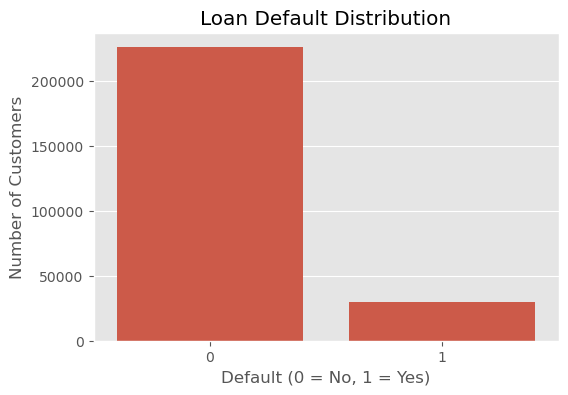

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Default')

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

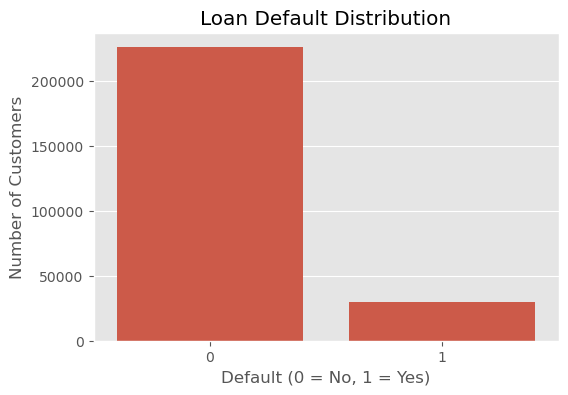

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Default')

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.savefig("../IMAGES/default_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

# Credit Score Analysis

## Objective
To determine whether customers with lower credit scores are more likely to default on their loans.

## Why this matters
Credit score is one of the strongest indicators of a customer's ability to repay a loan. Banks use credit scores to evaluate lending risk before approving loans.

In [20]:
# Average Credit Score by Default Status
credit_default = df.groupby("Default")["CreditScore"].mean()

print(credit_default)

Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64


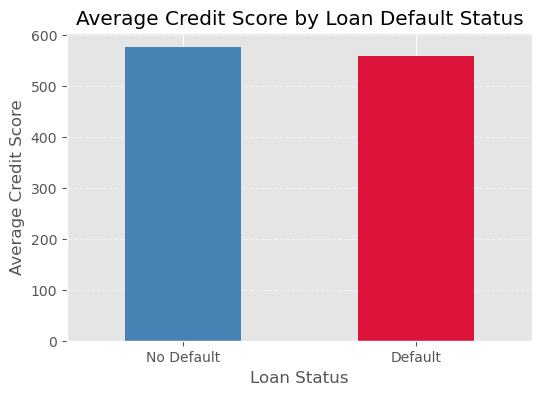

In [21]:
import matplotlib.pyplot as plt

credit_default.plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue", "crimson"]
)

plt.title("Average Credit Score by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Credit Score")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("../IMAGES/credit_score_analysis.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Income Analysis

## Objective
To examine whether customer income influences loan default.

## Why this matters
Income reflects a customer's repayment capacity. Customers with stable or higher incomes are generally expected to have a lower probability of default.

In [22]:
income_default = df.groupby("Default")["Income"].mean()

print(income_default)

Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64


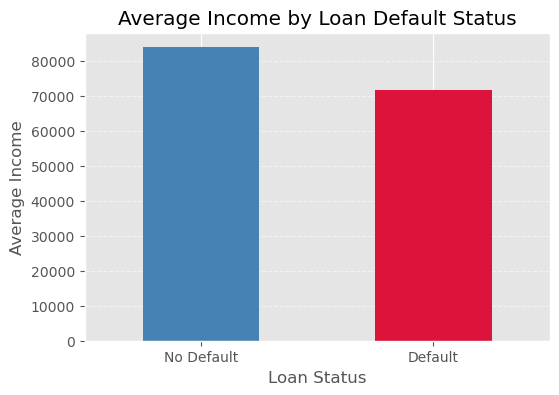

In [23]:
income_default.plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue", "crimson"]
)

plt.title("Average Income by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Income")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("../IMAGES/income_analysis.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Insight

This analysis compares the average income of customers who defaulted and those who did not.

The results help determine whether income is associated with repayment behavior and whether income should be considered during credit risk assessment.

# Loan Amount Analysis

## Objective
To investigate whether higher loan amounts increase the likelihood of loan default.

## Why this matters
Larger loans expose banks to greater financial risk. Understanding this relationship helps institutions optimize lending strategies.

In [24]:
loan_default = df.groupby("Default")["LoanAmount"].mean()

print(loan_default)

Default
0    125353.656017
1    144515.311469
Name: LoanAmount, dtype: float64


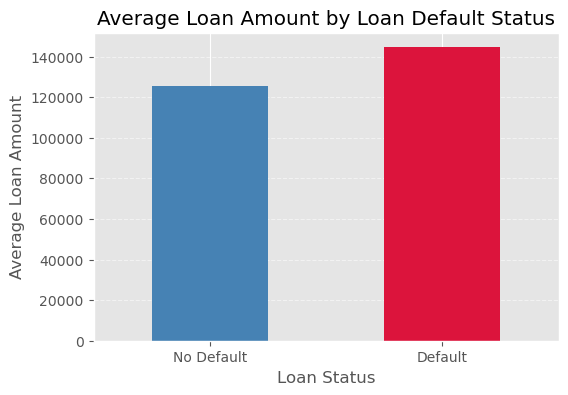

In [25]:
loan_default.plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue", "crimson"]
)

plt.title("Average Loan Amount by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("../IMAGES/loan_amount_analysis.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Insight

This analysis evaluates whether customers with larger loan amounts are more likely to default.

If higher loan amounts correspond to higher default rates, banks may consider implementing stricter approval criteria for high-value loans.

# Credit Score Analysis

## Objective
To determine whether customers with lower credit scores are more likely to default on their loans.

## Why this matters
Credit score is one of the strongest indicators of a customer's creditworthiness. Banks use credit scores to estimate the risk associated with lending money. Understanding this relationship helps financial institutions make better lending decisions and reduce default risk.

In [26]:
# Average Credit Score by Default Status

credit_default = df.groupby("Default")["CreditScore"].mean()

print(credit_default)

Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64


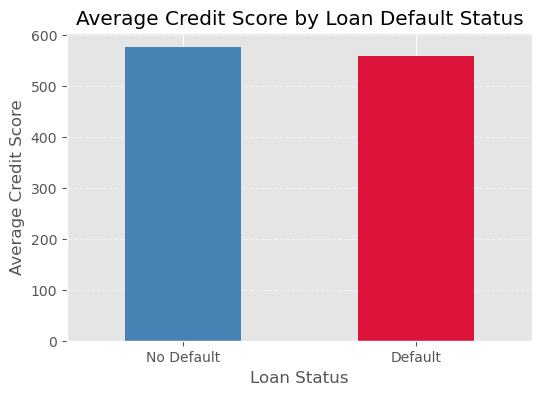

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

credit_default.plot(
    kind="bar",
    color=["steelblue", "crimson"]
)

plt.title("Average Credit Score by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Credit Score")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/credit_score_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Credit Score Distribution by Default Status

## Objective

To compare the distribution of credit scores between customers who defaulted and those who did not.

## Why this matters

Average values may hide important differences. Visualizing the full distribution helps determine whether customers with lower credit scores are more likely to default.

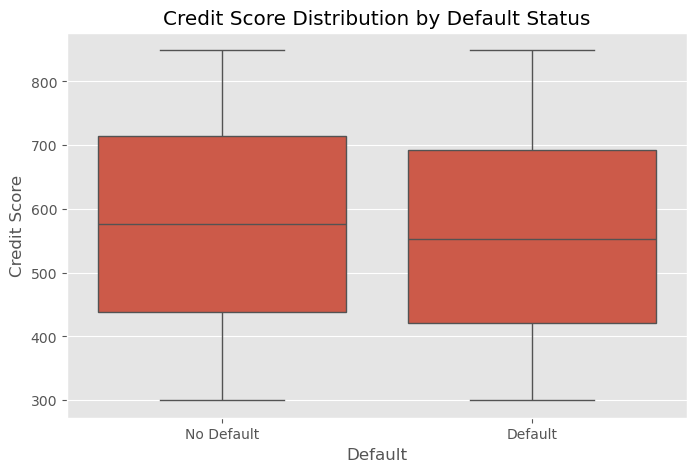

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Default",
    y="CreditScore"
)

plt.title("Credit Score Distribution by Default Status")
plt.xlabel("Default")
plt.ylabel("Credit Score")

plt.xticks([0,1], ["No Default","Default"])

plt.show()

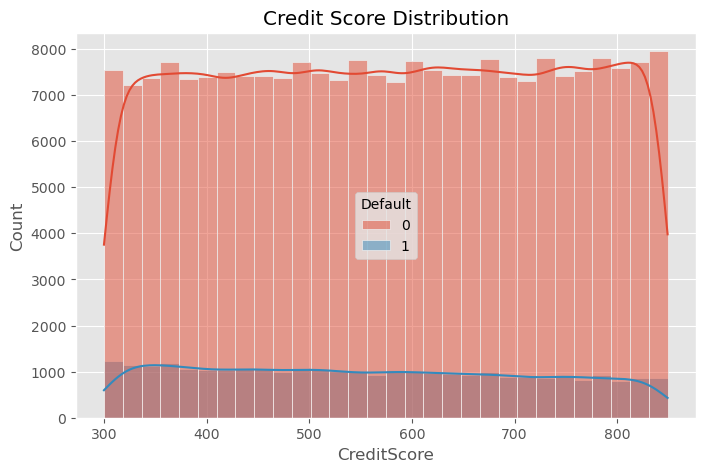

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="CreditScore",
    hue="Default",
    kde=True,
    bins=30
)

plt.title("Credit Score Distribution")

plt.show()

## Insight

The distribution of credit scores for customers who defaulted and those who did not is highly similar.

Both the boxplot and histogram indicate substantial overlap between the two groups, suggesting that credit score alone is not a strong predictor of loan default in this dataset.

Therefore, additional factors such as income, loan amount, debt-to-income ratio, and employment characteristics should be analyzed to better understand default risk.

## Business Recommendation

The bank should avoid relying solely on credit score when evaluating loan applications.

Instead, credit score should be combined with other financial and demographic variables to create a more comprehensive credit risk assessment model.

# Income Analysis

## Objective

To examine whether customer income influences loan default.

## Why this matters

Income reflects a customer's financial capacity to repay loans. Understanding its relationship with loan default helps banks evaluate borrower affordability and improve lending decisions.

In [30]:
# Average Income by Default Status

income_default = df.groupby("Default")["Income"].mean()

print(income_default)

Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64


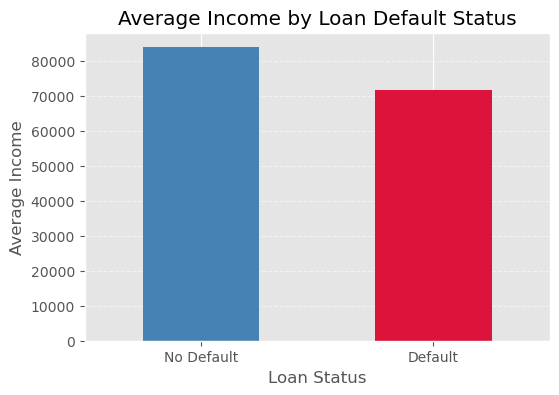

In [31]:
plt.figure(figsize=(6,4))

income_default.plot(
    kind="bar",
    color=["steelblue", "crimson"]
)

plt.title("Average Income by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Income")

plt.xticks([0,1], ["No Default","Default"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/income_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The average annual income of customers who did not default is approximately **83,899**, whereas customers who defaulted have an average income of approximately **71,845**.

This difference of nearly **12,000** suggests that customers with higher incomes are generally less likely to default on their loans. Higher income may improve a borrower's ability to meet repayment obligations, reducing the overall risk of default.

## Business Recommendation

Income should be considered as an important factor during the loan approval process.

Applicants with lower incomes may require additional affordability assessments or adjusted loan terms to reduce the likelihood of future loan defaults.

# Loan Amount Analysis

## Objective

To investigate whether larger loan amounts are associated with a higher likelihood of loan default.

## Why this matters

Higher loan amounts expose banks to greater financial risk. Understanding this relationship helps financial institutions develop effective lending strategies and minimize potential losses.

In [32]:
loan_default = df.groupby("Default")["LoanAmount"].mean()

print(loan_default)

Default
0    125353.656017
1    144515.311469
Name: LoanAmount, dtype: float64


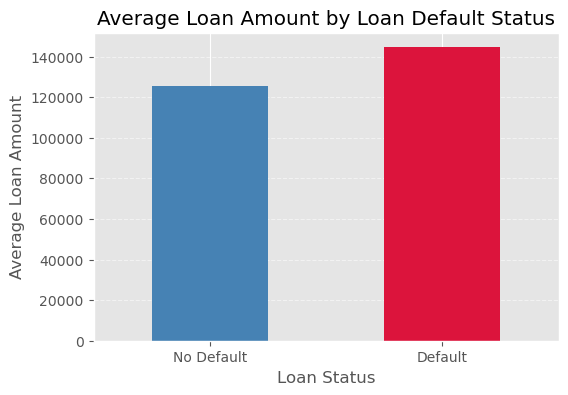

In [33]:
plt.figure(figsize=(6,4))

loan_default.plot(
    kind="bar",
    color=["steelblue", "crimson"]
)

plt.title("Average Loan Amount by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/loan_amount_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Customers who defaulted had an average loan amount of approximately **144,515**, compared to **125,354** for customers who successfully repaid their loans.

The difference of approximately **19,161** suggests that larger loan amounts are associated with a higher likelihood of loan default. Borrowers with larger loans may experience greater financial burden, increasing the probability of repayment difficulties.

## Business Recommendation

The bank should apply additional risk assessment procedures for high-value loan applications.

Applicants requesting larger loan amounts may require enhanced income verification, stronger credit evaluation, or additional collateral to reduce default risk.

# Debt-to-Income (DTI) Ratio Analysis

## Objective

To analyze whether customers with higher debt-to-income ratios are more likely to default on their loans.

## Why this matters

The Debt-to-Income (DTI) ratio measures the proportion of a customer's income that goes toward debt payments. A higher DTI ratio may indicate greater financial stress, making it an important indicator of loan repayment risk.

In [34]:
dti_default = df.groupby("Default")["DTIRatio"].mean()

print(dti_default)

Default
0    0.498602
1    0.512467
Name: DTIRatio, dtype: float64


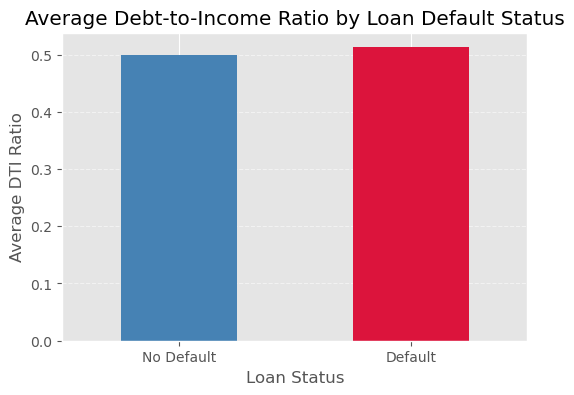

In [35]:
plt.figure(figsize=(6,4))

dti_default.plot(
    kind="bar",
    color=["steelblue", "crimson"]
)

plt.title("Average Debt-to-Income Ratio by Loan Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average DTI Ratio")

plt.xticks([0,1], ["No Default", "Default"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/dti_ratio_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Customers who defaulted have a slightly higher average Debt-to-Income (DTI) ratio (0.512) compared to customers who did not default (0.499).

Although the difference is relatively small, it suggests that borrowers with higher debt obligations relative to their income may be more likely to experience repayment difficulties.

## Business Recommendation

The bank should consider Debt-to-Income (DTI) ratio as one of several factors in its credit risk assessment.

Applicants with higher DTI ratios should undergo additional affordability checks before loan approval, particularly when combined with other risk factors such as lower income or higher loan amounts.

# Employment Type Analysis

## Objective

To determine whether employment type influences loan default.

## Why this matters

Employment stability plays a significant role in a customer's ability to repay loans. Analyzing default rates across different employment categories helps banks identify high-risk customer segments and improve lending decisions.

In [36]:
employment_default = pd.crosstab(
    df["EmploymentType"],
    df["Default"],
    normalize="index"
) * 100

employment_default.round(2)

Default,0,1
EmploymentType,,
Full-time,90.54,9.46
Part-time,88.03,11.97
Self-employed,88.54,11.46
Unemployed,86.45,13.55


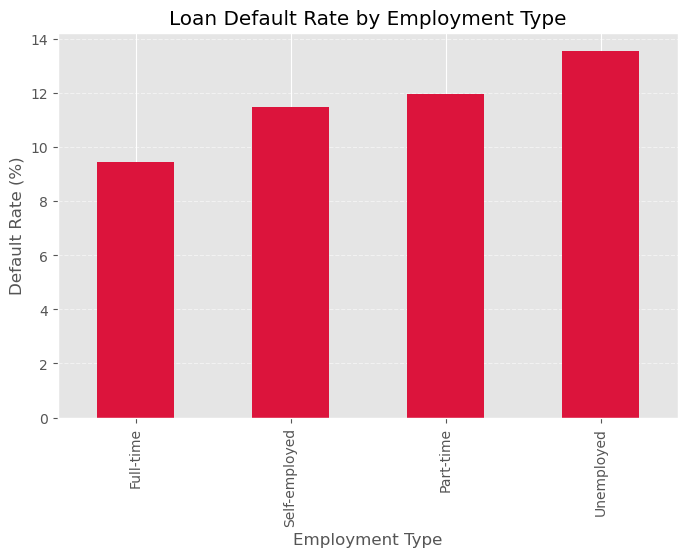

In [37]:
plt.figure(figsize=(8,5))

employment_default[1].sort_values().plot(
    kind="bar",
    color="crimson"
)

plt.title("Loan Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/employment_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The analysis shows that **Unemployed** customers have the highest loan default rate, while **Full-time** employees have the lowest.

This suggests that employment stability plays an important role in loan repayment behavior. Customers with stable full-time employment appear to have a lower risk of default, whereas unemployed borrowers are more likely to experience repayment difficulties.

Although the difference is moderate rather than extreme, employment type should still be considered as an important factor in credit risk assessment.

## Business Recommendation

The bank should incorporate employment type into its loan approval and risk assessment process.

Loan applications from unemployed individuals may require additional verification, stronger financial documentation, or adjusted lending terms. Customers with stable full-time employment may represent a lower-risk borrower segment.

# Education Analysis

## Objective

To determine whether education level influences loan default.

## Why this matters

Education may be associated with employment opportunities, earning potential, and financial stability. Understanding default rates across education levels helps banks better understand borrower risk.

In [38]:
education_default = pd.crosstab(
    df["Education"],
    df["Default"],
    normalize="index"
) * 100

education_default.round(2)

Default,0,1
Education,,
Bachelor's,87.90,12.10
High School,87.12,12.88
Master's,89.13,10.87
PhD,89.41,10.59


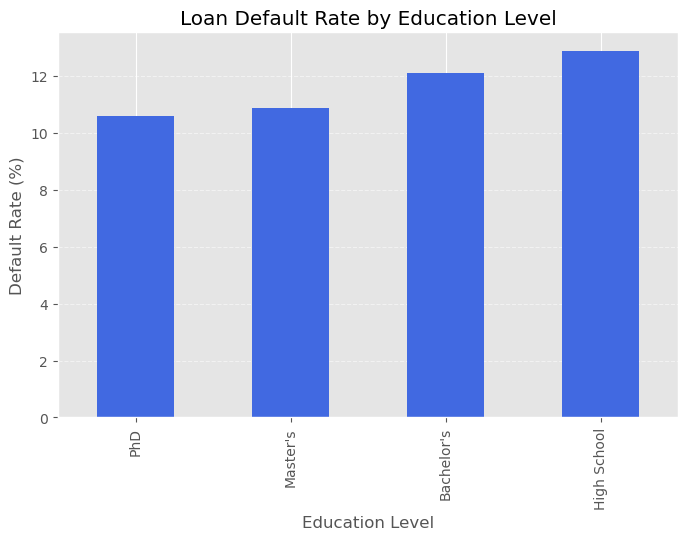

In [39]:
plt.figure(figsize=(8,5))

education_default[1].sort_values().plot(
    kind="bar",
    color="royalblue"
)

plt.title("Loan Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/education_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The default rates across different education levels range from approximately **10.5% to 13%**, indicating only a small variation.

Although some education groups exhibit slightly higher default rates than others, education alone does not appear to be a strong predictor of loan default in this dataset. Other financial factors such as income, loan amount, and employment status are likely to have a greater influence on repayment behavior.

## Business Recommendation

Education level should not be used as a primary factor in loan approval decisions.

Instead, banks should combine education with other financial indicators such as income, employment status, debt-to-income ratio, and loan amount to achieve a more accurate assessment of borrower risk.

# Loan Purpose Analysis

## Objective

To identify whether the purpose of a loan influences the likelihood of loan default.

## Why this matters

Different loan purposes may carry different levels of financial risk. Understanding default rates by loan purpose enables banks to design better lending policies and improve risk management strategies.

In [40]:
loanpurpose_default = pd.crosstab(
    df["LoanPurpose"],
    df["Default"],
    normalize="index"
) * 100

loanpurpose_default.round(2)

Default,0,1
LoanPurpose,,
Auto,88.12,11.88
Business,87.67,12.33
Education,88.16,11.84
Home,89.77,10.23
Other,88.21,11.79


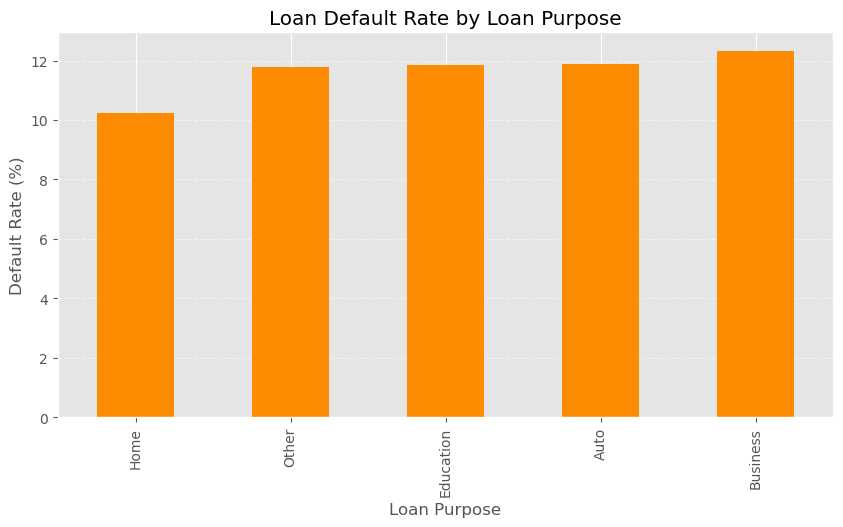

In [41]:
plt.figure(figsize=(10,5))

loanpurpose_default[1].sort_values().plot(
    kind="bar",
    color="darkorange"
)

plt.title("Loan Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/loan_purpose_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Marital Status Analysis

## Objective

To determine whether marital status influences loan default.

## Why this matters

Marital status may influence financial responsibilities and household income. Analyzing loan default rates across different marital status groups helps determine whether it has any significant impact on repayment behavior.

In [42]:
# Default Rate by Marital Status

marital_default = pd.crosstab(
    df["MaritalStatus"],
    df["Default"],
    normalize="index"
) * 100

marital_default.round(2)

Default,0,1
MaritalStatus,,
Divorced,87.47,12.53
Married,89.60,10.40
Single,88.09,11.91


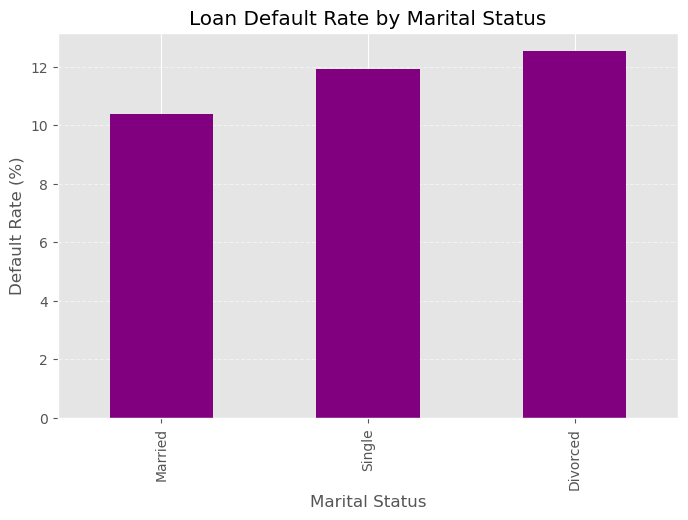

In [43]:
plt.figure(figsize=(8,5))

marital_default[1].sort_values().plot(
    kind="bar",
    color="purple"
)

plt.title("Loan Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/marital_status_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The analysis shows only a small variation in loan default rates across different marital status groups.

Divorced customers have the highest default rate, while married customers have the lowest. However, the difference between the groups is relatively small, indicating that marital status alone is not a strong predictor of loan default.

Financial factors such as income, loan amount, and employment status are likely to have a greater influence on repayment behavior.

## Business Recommendation

Marital status should not be used as a primary criterion for loan approval decisions.

Instead, it should be considered alongside more significant financial indicators such as income, employment status, debt-to-income ratio, and loan amount to improve credit risk assessment.

# Mortgage Analysis

## Objective

To determine whether having an existing mortgage influences loan default.

## Why this matters

Customers with an existing mortgage may have additional financial obligations that could affect their ability to repay new loans. This analysis helps evaluate whether mortgage ownership is associated with loan default risk.

In [44]:
# Default Rate by Mortgage Status

mortgage_default = pd.crosstab(
    df["HasMortgage"],
    df["Default"],
    normalize="index"
) * 100

mortgage_default.round(2)

Default,0,1
HasMortgage,,
No,87.65,12.35
Yes,89.12,10.88


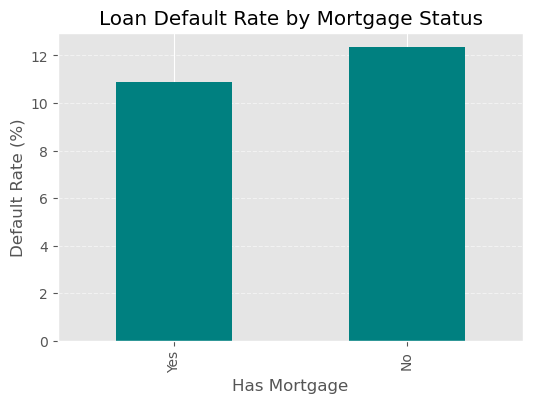

In [45]:
plt.figure(figsize=(6,4))

mortgage_default[1].sort_values().plot(
    kind="bar",
    color="teal"
)

plt.title("Loan Default Rate by Mortgage Status")
plt.xlabel("Has Mortgage")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/mortgage_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Customers with an existing mortgage have a slightly higher loan default rate (12.2%) compared to customers without a mortgage (10.9%).

The difference is relatively small, suggesting that mortgage ownership alone is not a strong predictor of loan default. However, existing mortgage obligations may contribute to a customer's overall financial burden when combined with other risk factors.

## Business Recommendation

Mortgage ownership should be considered as one component of a comprehensive credit risk assessment rather than as an independent approval criterion.

Banks should evaluate mortgage status alongside income, debt-to-income ratio, loan amount, and employment stability to make more informed lending decisions.

# Dependents Analysis

## Objective

To determine whether having dependents influences loan default.

## Why this matters

Customers with dependents often have additional financial responsibilities that may affect their ability to repay loans. This analysis helps identify whether family obligations are associated with higher loan default risk.

In [46]:
# Default Rate by Dependents Status

dependents_default = pd.crosstab(
    df["HasDependents"],
    df["Default"],
    normalize="index"
) * 100

dependents_default.round(2)

Default,0,1
HasDependents,,
No,87.28,12.72
Yes,89.50,10.50


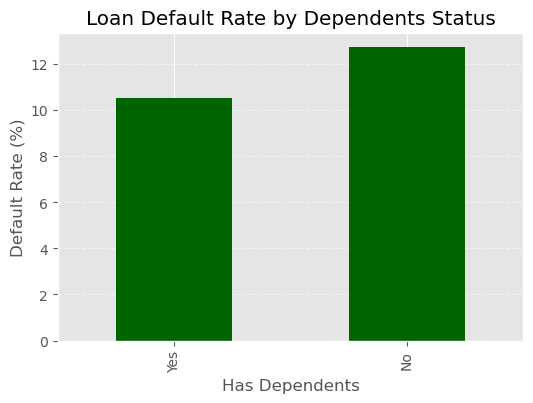

In [47]:
plt.figure(figsize=(6,4))

dependents_default[1].sort_values().plot(
    kind="bar",
    color="darkgreen"
)

plt.title("Loan Default Rate by Dependents Status")
plt.xlabel("Has Dependents")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/dependents_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Customers with dependents have a slightly higher loan default rate than customers without dependents.

However, the difference is relatively small, indicating that having dependents alone is not a strong predictor of loan default. Financial variables such as income, loan amount, and employment status appear to have a greater influence on repayment behavior.

## Business Recommendation

The presence of dependents should be considered as part of a broader borrower profile rather than as an independent indicator of credit risk.

Banks should prioritize stronger financial indicators such as income, debt-to-income ratio, employment stability, and loan amount when evaluating loan applications.

# Co-Signer Analysis

## Objective

To determine whether having a co-signer influences loan default.

## Why this matters

A co-signer provides additional financial security for the lender. Understanding whether borrowers with co-signers have lower default rates helps evaluate the effectiveness of requiring co-signers during the loan approval process.

In [48]:
# Default Rate by Co-Signer Status

cosigner_default = pd.crosstab(
    df["HasCoSigner"],
    df["Default"],
    normalize="index"
) * 100

cosigner_default.round(2)

Default,0,1
HasCoSigner,,
No,87.13,12.87
Yes,89.64,10.36


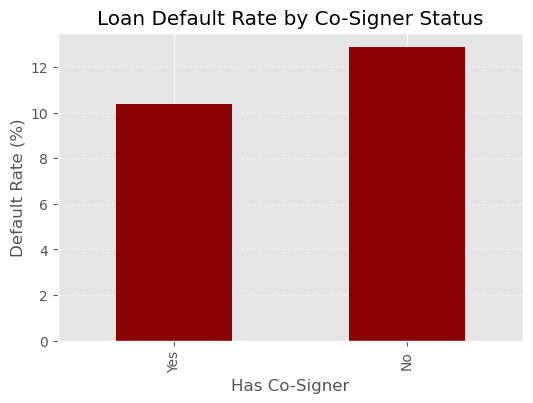

In [49]:
plt.figure(figsize=(6,4))

cosigner_default[1].sort_values().plot(
    kind="bar",
    color="darkred"
)

plt.title("Loan Default Rate by Co-Signer Status")
plt.xlabel("Has Co-Signer")
plt.ylabel("Default Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../IMAGES/cosigner_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Customers with and without a co-signer exhibit very similar loan default rates.

The small difference indicates that having a co-signer alone does not significantly influence the likelihood of loan default in this dataset.

This suggests that stronger financial indicators such as income, loan amount, and employment status play a more important role in predicting loan repayment behavior.

## Business Recommendation

The presence of a co-signer should not be used as the sole basis for loan approval decisions.

Instead, banks should evaluate co-signer information alongside other key financial variables to build a more comprehensive and accurate credit risk assessment.

# Correlation Analysis

## Objective

To examine the relationships between numerical variables and identify patterns that may influence loan default.

## Why this matters

Correlation analysis helps identify variables that move together. Understanding these relationships enables financial institutions to recognize key risk indicators and improve predictive modeling.

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr_matrix = numerical_df.corr()

corr_matrix

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


In [77]:
## 🌲 Feature Importance Analysis

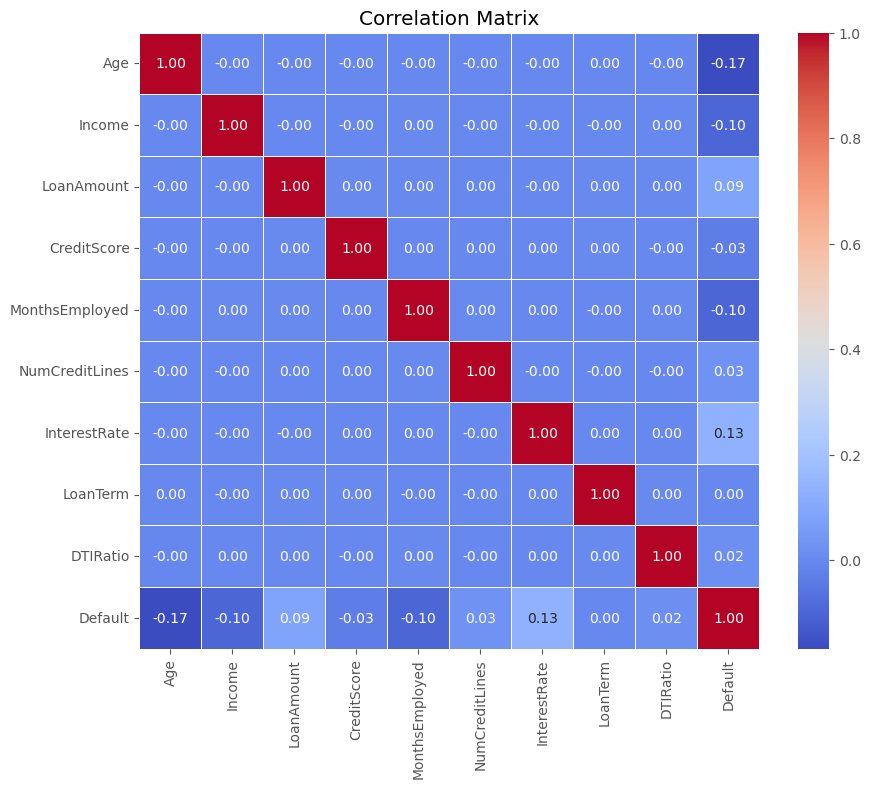

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.savefig(
    "../IMAGES/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Correlation Analysis

## Insight

The correlation analysis indicates that no numerical feature has a strong linear relationship with loan default.

Among the variables analyzed:

- **Age (-0.17)** shows the strongest negative correlation with default, suggesting that older customers are slightly less likely to default.
- **Interest Rate (0.13)** has the strongest positive correlation, indicating that higher interest rates are associated with a slightly greater likelihood of default.
- **Income (-0.10)** and **Months Employed (-0.10)** show weak negative relationships with default.
- **Loan Amount (0.09)** has a weak positive relationship with default.
- **Credit Score (-0.03)** and **DTI Ratio (0.02)** exhibit almost no linear relationship with loan default.

Overall, the low correlation values suggest that loan default is influenced by multiple factors rather than a single numerical variable.

## Business Recommendation

Banks should avoid relying on any single numerical variable when assessing loan default risk.

Instead, multiple financial indicators—including income, loan amount, employment history, and interest rate—should be evaluated together to improve credit risk assessment and lending decisions.

# Feature Importance Analysis

## Objective

To identify the most influential features used by a machine learning model to predict loan default.

## Why this matters

Feature importance helps determine which customer characteristics contribute the most to loan default prediction. This enables financial institutions to focus on the most relevant variables during credit risk assessment and improve lending decisions.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [53]:
# Create a copy of the dataset
df_ml = df.copy()

# Convert categorical columns into numerical values
le = LabelEncoder()

for column in df_ml.select_dtypes(include="object").columns:
    df_ml[column] = le.fit_transform(df_ml[column])

df_ml.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,128027,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,125442,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,85333,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,220129,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,105746,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [59]:
X = df_ml.drop(["LoanID", "Default"], axis=1)
y = df_ml["Default"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Income,0.131769
6,InterestRate,0.125128
2,LoanAmount,0.120112
3,CreditScore,0.103713
0,Age,0.098788
4,MonthsEmployed,0.098497
8,DTIRatio,0.089347
7,LoanTerm,0.038503
14,LoanPurpose,0.038095
5,NumCreditLines,0.031478


# Feature Importance Analysis

## Insight

The Random Forest model identified **Income**, **Interest Rate**, and **Loan Amount** as the three most influential variables for predicting loan default.

Income emerged as the strongest predictor, indicating that a customer's financial capacity plays a critical role in loan repayment behavior. Interest Rate and Loan Amount were also highly important, suggesting that borrowing cost and loan size significantly influence credit risk.

Although Credit Score showed only a weak linear correlation with loan default, the machine learning model assigned it relatively high importance. This indicates that Credit Score contributes through more complex, non-linear relationships that are not captured by simple correlation analysis.

Variables such as Mortgage Status, Dependents, and Co-Signer had the lowest importance scores, indicating that they contribute relatively little to predicting loan default.

## Business Recommendation

Banks should prioritize financial indicators such as income, interest rate, loan amount, credit score, and employment history when assessing loan applications.

Household-related variables such as mortgage ownership, dependents, and co-signer status should be treated as supporting information rather than primary approval criteria.

Combining multiple financial indicators through predictive models can improve loan approval decisions and reduce default risk.

# Executive Summary

## Business Problem

Banks face significant financial losses due to loan defaults. The objective of this project was to identify the factors influencing loan default and provide data-driven recommendations to improve credit risk assessment.

## Dataset Overview

- Total Records: **255,347**
- Total Features: **18**
- Target Variable: **Default**
- Default Rate: **11.61%**
- Non-Default Rate: **88.39%**

## Key Findings

- Customers with higher incomes were less likely to default.
- Larger loan amounts were associated with higher default rates.
- Higher interest rates slightly increased the likelihood of default.
- Longer employment history was associated with lower default risk.
- Credit Score had limited linear correlation but was identified as an important predictor by the Random Forest model.
- Mortgage status, dependents, and co-signer information had relatively low predictive importance.

## Conclusion

Financial characteristics play a much larger role in predicting loan default than demographic or household-related factors.

The findings suggest that banks should prioritize income, loan amount, interest rate, employment history, and credit score when evaluating loan applications.

# Final Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Prioritize customer income during credit evaluation, as it is the strongest predictor of loan repayment.

2. Apply additional risk assessment for customers requesting high loan amounts.

3. Monitor borrowers with higher interest rates, as they exhibit a greater likelihood of default.

4. Consider employment stability and work experience when evaluating loan applications.

5. Use machine learning models alongside traditional credit assessment methods to improve loan approval decisions.

6. Avoid relying heavily on demographic variables such as marital status, mortgage ownership, dependents, or co-signer information, as they contribute relatively little to loan default prediction.

In [63]:
import os
print(os.getcwd())

C:\Users\Administrator\Desktop\Bank-Loan-Risk-Analysis\python


In [64]:
import os

print(os.listdir("../images"))

['.ipynb_checkpoints', 'correlation_matrix.png', 'cosigner_default_rate.png', 'credit_score_analysis.png', 'default_distribution.png', 'dependents_default_rate.png', 'dti_ratio_analysis.png', 'education_default_rate.png', 'employment_default_rate.png', 'income_analysis.png', 'loan_amount_analysis.png', 'loan_purpose_default_rate.png', 'marital_status_default_rate.png', 'mortgage_default_rate.png']


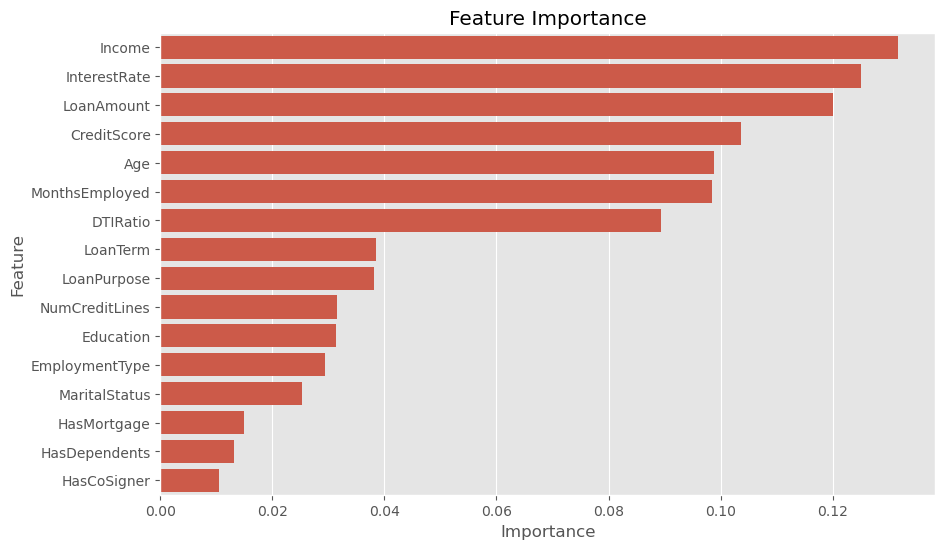

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("../images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [66]:
import os
print(os.listdir("../images"))

['.ipynb_checkpoints', 'correlation_matrix.png', 'cosigner_default_rate.png', 'credit_score_analysis.png', 'default_distribution.png', 'dependents_default_rate.png', 'dti_ratio_analysis.png', 'education_default_rate.png', 'employment_default_rate.png', 'feature_importance.png', 'income_analysis.png', 'loan_amount_analysis.png', 'loan_purpose_default_rate.png', 'marital_status_default_rate.png', 'mortgage_default_rate.png']


In [67]:
import os
print(os.listdir("../images"))

['.ipynb_checkpoints', 'correlation_matrix.png', 'cosigner_default_rate.png', 'credit_score_analysis.png', 'default_distribution.png', 'dependents_default_rate.png', 'dti_ratio_analysis.png', 'education_default_rate.png', 'employment_default_rate.png', 'feature_importance.png', 'income_analysis.png', 'loan_amount_analysis.png', 'loan_purpose_default_rate.png', 'marital_status_default_rate.png', 'mortgage_default_rate.png']
